In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import re
import warnings #Used in order to ignore the warnings messages showed through the notebook
warnings.filterwarnings('ignore') #Setting to ignore the warnings

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
# Loading the train and test file to a dataframe using Pandas

train_set = pd.read_csv('../input/spaceship-titanic/train.csv')
test_set = pd.read_csv('../input/spaceship-titanic/test.csv')

## Describing the variables

PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.

CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. 
Passengers in cryosleep are confined to their cabins.

Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.

Destination - The planet the passenger will be debarking to.

Age - The age of the passenger.

VIP - Whether the passenger has paid for special VIP service during the voyage.

RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.

Name - The first and last names of the passenger.

Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

In [3]:
# Checking the data from the first lines

train_set.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
# Checking the statistics from the numerical features

train_set.describe() 

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
# Checking dtype and missing values for each feature in the train set

train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
# Checking dtype and missing values for each feature in the test set

test_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


## Concatenating the data before the transformation

Since we will execute transformations, some that envolves the values both from the train and test data, it is easier to concatenate them and separate after the steps below.

In [7]:
# Appending the dataframes using pd.concat

df = pd.concat([train_set, test_set])

In [8]:
# Checking the data

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12970 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
 13  Transported   8693 non-null   object 
dtypes: float64(6), object(8)
memory usage: 1.5+ MB


## Dealing with missing values

In [9]:
# Counting rows with missing values

df.isna().any(axis=1).sum()

6364

In [10]:
# Printing the percentage of 8693 rows that has at least one column with missing value.

print('The total of rows with missing values is: ', round((df.isna().any(axis=1).sum()/len(df.index)*100),2),'%')

The total of rows with missing values is:  49.07 %


## Approaching missing values

After looking the attributes, we decided to replace categorical missing values with 'unknown' values, and for the numeric values, should be replaced with the median.

Only for Cabin that has a different format, will be replaced by U/0/U, as Unknown/0/Unknown.

## Cattegorical attributes

In [11]:
# Creating a Dictionary selecting the object dtype columns, except for Cabin, CryoSleep and VIP.

cols_to_replace = {'HomePlanet': 'Unknown', 'Destination': 'Unknown', 'Name': 'Unknown'}

In [12]:
# Replacing the missing values into the specified columns from the dictionary

# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html

df.fillna(value = cols_to_replace, inplace = True)

In [13]:
# Checking the non-null values, it worked!

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12970 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12970 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12970 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12970 non-null  object 
 13  Transported   8693 non-null   object 
dtypes: float64(6), object(8)
memory usage: 1.5+ MB


In [14]:
# Replacing Cabin missing values

df.fillna({'Cabin':'U/0/U'}, inplace = True)

### Dealing with columns with False/True values

Even though CryoSleep and VIP are not boolean dtype, there is some issue replacing it as numbers if we insert missing values as 'Unknown' now.

Then it is better to replace the N/A values with a digit (we will use 9 for the case, but it is arbitrary, it will not impact in the final prediction).

In [15]:
# Inserting 9 in the CryoSleep missing values

df.fillna({'CryoSleep':9}, inplace = True)

In [16]:
# Casting it into int dtype

df['CryoSleep'] = df['CryoSleep'].astype(int)

In [17]:
# Checking if everything worked as expected.

df['CryoSleep'].value_counts()

0    8079
1    4581
9     310
Name: CryoSleep, dtype: int64

In [18]:
# Inserting 9 in the VIP missing values

df.fillna({'VIP':9}, inplace = True)

In [19]:
# Casting it into int dtype and checking

df['VIP'] = df['VIP'].astype(int)
df['VIP'].value_counts()

0    12401
9      296
1      273
Name: VIP, dtype: int64

## Numerical Attributes

In [20]:
# Replacing missing values by the median of each feature, first let's attribute the columns to a variable

cols_median = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [21]:
# Replacing the missing values in the columns selected

df[cols_median] = df[cols_median].fillna(df[cols_median].median())

## Generating new attributes from PassengerId and Cabin

After looking all the attributes, there is possible a correlation between the group the passenger is traveling with, and the location of the cabin, within the transportation of the passenger. To check if this assumption is true, first we need to separate the information from PassengerId and Cabin in a way that it can be calculated the correlation.

### Code for "PassengerId"

In [22]:
# Checking the values from PassengerId

df['PassengerId'].value_counts()

0001_01    1
9227_03    1
9220_01    1
9220_02    1
9220_03    1
          ..
4610_01    1
4611_01    1
4612_01    1
4613_01    1
9277_01    1
Name: PassengerId, Length: 12970, dtype: int64

In [23]:
# After checking, we can extract the first 4 digits to separate the groups and create a new column

group = df['PassengerId'].str[:4]

In [24]:
# Inserting the new column as GroupId in the initial Dataframe

df.insert(loc = 1, column='GroupId', value = group)

In [25]:
# Checking if the new column was succesfully inserted

df.head()

,PassengerId,GroupId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,0001,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,0002,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,0003,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,0003,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,0004,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### Code for "Cabin"

In [26]:
# Extracting the deck information from Cabin

deck = df['Cabin'].str[:1]

In [27]:
# Checking how many different values we have

deck.value_counts()

F    4239
G    3781
E    1323
B    1141
C    1102
D     720
A     354
U     299
T      11
Name: Cabin, dtype: int64

In [28]:
# Inserting the new column as CabinDeck in the initial Dataframe

df.insert(loc = 5, column='CabinDeck', value = deck)

In [29]:
# Checking the inserted CabinDeck column

df.head()

,PassengerId,GroupId,HomePlanet,CryoSleep,Cabin,CabinDeck,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,0001,Europa,0,B/0/P,B,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,0002,Earth,0,F/0/S,F,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,0003,Europa,0,A/0/S,A,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,0003,Europa,0,A/0/S,A,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,0004,Earth,0,F/1/S,F,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [30]:
# Creating a dictionary to replace the letters for numbers into the CabinDeck column

deck_sub = {'U':0, 'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7, 'T':8}

In [31]:
# Replacing and checking the change, it worked!

df.replace({'CabinDeck':deck_sub}, inplace = True)

In [32]:
df.head()

,PassengerId,GroupId,HomePlanet,CryoSleep,Cabin,CabinDeck,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,0001,Europa,0,B/0/P,2,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,0002,Earth,0,F/0/S,6,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,0003,Europa,0,A/0/S,1,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,0003,Europa,0,A/0/S,1,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,0004,Earth,0,F/1/S,6,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### Let's repeat the steps above to get the num and side from the Cabin

In [33]:
# Extracting information

num = df['Cabin'].str[2:-2]
side = df['Cabin'].str[-1:]

In [34]:
# Creating columns

df.insert(loc = 6, column='CabinNum', value = num)
df.insert(loc = 7, column='CabinSide', value = side)

## Manipulating categorical attributes with more than 2 categories

Now we will transform all the categorical variables with more than 2 categories into numbers as was done with the CabinDeck attribute.

In [35]:
# Checking how many values "HomePlanet" does have.

df['HomePlanet'].value_counts()

Earth      6865
Europa     3133
Mars       2684
Unknown     288
Name: HomePlanet, dtype: int64

In [36]:
# Checking how many values "Destination" does have.

df['Destination'].value_counts()

TRAPPIST-1e      8871
55 Cancri e      2641
PSO J318.5-22    1184
Unknown           274
Name: Destination, dtype: int64

### CryoSleep, CabinSide, and VIP

At the beggining CryoSleep and VIP had 2 categories (True or False), and CabinSide also had 2 categories (P or S), but Unknown was added so they all have 3 categories now.

In [37]:
# Creating a dictionary to replace the values for numbers:

homeplanet = {'Unknown':0, 'Earth':1, 'Europa':2, 'Mars':3}
cab_side = {'U':0, 'P':1, 'S':2}
dest = {'Unknown':0, 'TRAPPIST-1e':1, '55 Cancri e':2, 'PSO J318.5-22':3}

In [38]:
# Replacing and checking the change, it worked!

df.replace({'HomePlanet':homeplanet, 'CabinSide':cab_side, 'Destination':dest}, inplace = True)

In [39]:
# GroupId, CabinNum and CabinSide must be changed from object to int.

df['GroupId'] = df['GroupId'].astype('int')
df['CabinNum'] = df['CabinNum'].astype('int')
df['CabinSide'] = df['CabinSide'].astype('int')

### Creating last name column from name and finding number of relatives

In [40]:
# Extracting last name using str.split, using -1 as index it means it will 
# extract from the last blank space till the last string [-1]

lname = df['Name'].str.split(' ').str[-1]

In [41]:
# Inserting the column after name

df.insert(loc = 17, column = 'Lastname', value = lname)

In [42]:
# Counting the values of repeated last names, we will transform into number of relatives later

df['Lastname'].value_counts()

Unknown       294
Belley         19
Buckentry      19
Casonston      18
Hinglendez     18
             ... 
Cabraseed       1
Miste           1
Imotive         1
Gepie           1
Replic          1
Name: Lastname, Length: 2407, dtype: int64

In [43]:
# Using the map function with the count of values we can extract the number of relatives for each value

relatives = df['Lastname'].map(df['Lastname'].value_counts())

In [44]:
# Since it does return the value count for each repetition of the last name, and the number of 
# relatives for each individual is the value count minus his own last name, we should subtract 1 for each value

relatives = relatives - 1

In [45]:
# For the unknown count we should imply that it has no relatives aboard, so we are going to replace its count

relatives.replace({293:0}, inplace = True)

In [46]:
# Inserting the column

df.insert(loc = 18, column='Relatives', value = relatives)

In [47]:
# Relatives must be changed from object to int.

df['Relatives'] = df['Relatives'].astype('int')

## Separating the train set from the test set

In [48]:
# Getting the 8693 rows to the train_df and the remaining to the test_df

train_df = df.iloc[:8693, :]
test_df = df.iloc[8693:, :]

In [49]:
# Checking the train_df

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8693 entries, 0 to 8692
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   GroupId       8693 non-null   int64  
 2   HomePlanet    8693 non-null   int64  
 3   CryoSleep     8693 non-null   int64  
 4   Cabin         8693 non-null   object 
 5   CabinDeck     8693 non-null   int64  
 6   CabinNum      8693 non-null   int64  
 7   CabinSide     8693 non-null   int64  
 8   Destination   8693 non-null   int64  
 9   Age           8693 non-null   float64
 10  VIP           8693 non-null   int64  
 11  RoomService   8693 non-null   float64
 12  FoodCourt     8693 non-null   float64
 13  ShoppingMall  8693 non-null   float64
 14  Spa           8693 non-null   float64
 15  VRDeck        8693 non-null   float64
 16  Name          8693 non-null   object 
 17  Lastname      8693 non-null   object 
 18  Relatives     8693 non-null 

In [50]:
# Checking the test_df

test_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4277 entries, 0 to 4276
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   GroupId       4277 non-null   int64  
 2   HomePlanet    4277 non-null   int64  
 3   CryoSleep     4277 non-null   int64  
 4   Cabin         4277 non-null   object 
 5   CabinDeck     4277 non-null   int64  
 6   CabinNum      4277 non-null   int64  
 7   CabinSide     4277 non-null   int64  
 8   Destination   4277 non-null   int64  
 9   Age           4277 non-null   float64
 10  VIP           4277 non-null   int64  
 11  RoomService   4277 non-null   float64
 12  FoodCourt     4277 non-null   float64
 13  ShoppingMall  4277 non-null   float64
 14  Spa           4277 non-null   float64
 15  VRDeck        4277 non-null   float64
 16  Name          4277 non-null   object 
 17  Lastname      4277 non-null   object 
 18  Relatives     4277 non-null 

## Transforming the target to int

In [51]:
train_df['Transported'].value_counts()

True     4378
False    4315
Name: Transported, dtype: int64

In [52]:
train_df['Transported'] = train_df['Transported'].astype('int64')

In [53]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8693 entries, 0 to 8692
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   GroupId       8693 non-null   int64  
 2   HomePlanet    8693 non-null   int64  
 3   CryoSleep     8693 non-null   int64  
 4   Cabin         8693 non-null   object 
 5   CabinDeck     8693 non-null   int64  
 6   CabinNum      8693 non-null   int64  
 7   CabinSide     8693 non-null   int64  
 8   Destination   8693 non-null   int64  
 9   Age           8693 non-null   float64
 10  VIP           8693 non-null   int64  
 11  RoomService   8693 non-null   float64
 12  FoodCourt     8693 non-null   float64
 13  ShoppingMall  8693 non-null   float64
 14  Spa           8693 non-null   float64
 15  VRDeck        8693 non-null   float64
 16  Name          8693 non-null   object 
 17  Lastname      8693 non-null   object 
 18  Relatives     8693 non-null 

## Checking the correlation between features and target

In [54]:
# Compute the standard correlation coefficient (also called Pearson’s r) 
# between every pair of attributes using the corr() method:

corr = train_df.corr()

In [55]:
# Checking the values from using "Transported" as reference to the correlation

corr["Transported"].sort_values(ascending=False)

Transported     1.000000
CryoSleep       0.148763
HomePlanet      0.110443
CabinSide       0.093497
Destination     0.065065
FoodCourt       0.045583
GroupId         0.021491
ShoppingMall    0.009391
VIP            -0.001407
CabinNum       -0.043832
Relatives      -0.053306
Age            -0.074233
CabinDeck      -0.104786
VRDeck         -0.204874
Spa            -0.218545
RoomService    -0.241124
Name: Transported, dtype: float64

<AxesSubplot:>

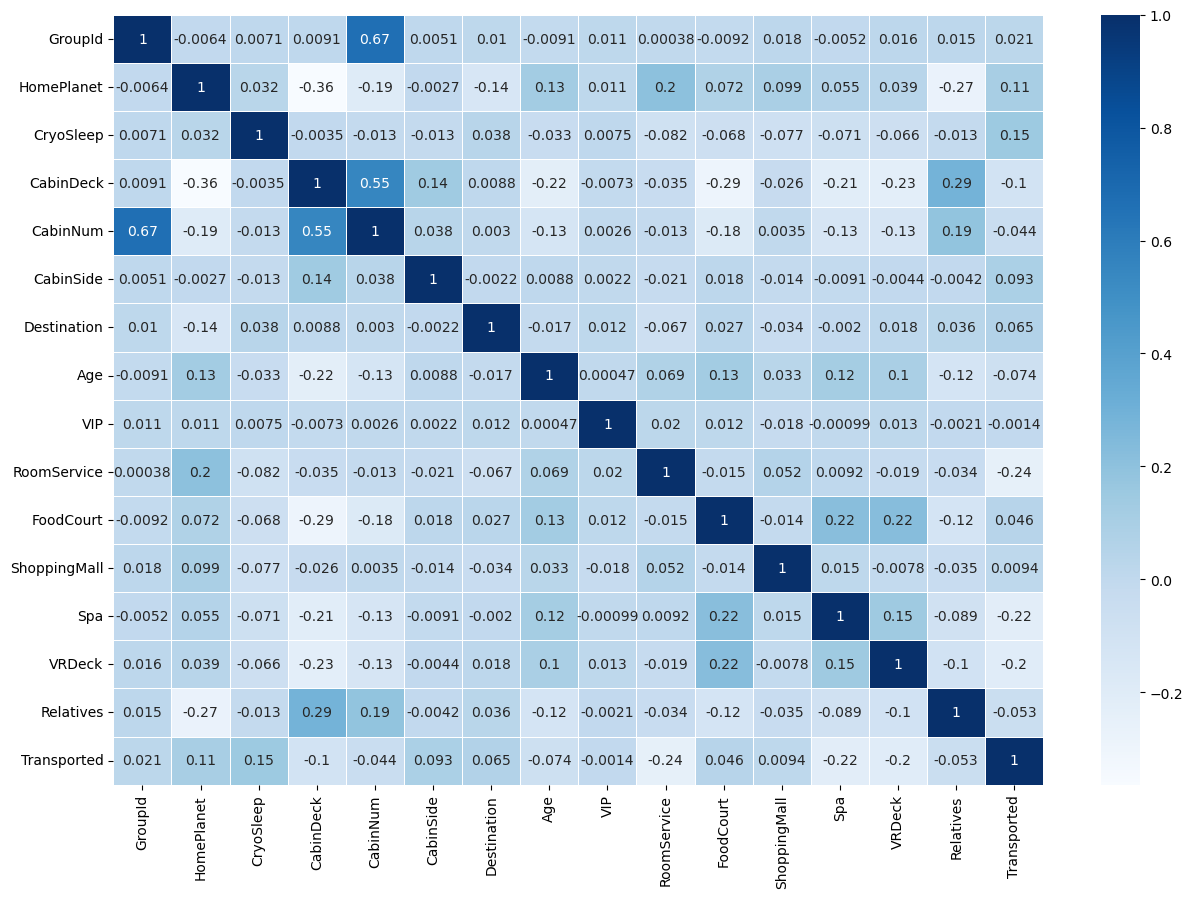

In [56]:
# Using seaborn to show the correlation map

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize = (15,10))         # Sample figsize in inches
sns.heatmap(corr, cmap = "Blues", annot = True, linewidths = 0.5, ax = ax)

## About the correlation map

Was possible to observe the RoomService, Spa and VRDeck have similiar negative correlation with the Transported, possibly indicating that they can impact whether the passenger were transported or not. Is it possible that people who spent more in luxury amenities have a higher or lower chance to get transported?

The CabinNum has a strong correlation within the GroupId, but it does have a correlation of only 0.021 with Transported, would the GroupId impact in the target?

In the next version of the notebook some transformations can be executed to check it and more.

## Separating the target values 

In [57]:
# Creating features without labels and categorical values

features = train_df.drop(['PassengerId', 'Cabin', 'Name', 'Lastname', 'Transported'], axis = 1)

In [58]:
# Extracting the labels

labels = train_df['Transported']

In [59]:
# Using a RandomForestClassifier and a Cross Validation Score to check the accuracy

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

forest_clf = RandomForestClassifier(n_estimators = 100, random_state = 42)
forest_scores = cross_val_score(forest_clf, features, labels, cv = 10)
forest_scores.mean()

0.7760356070526301

In [60]:
# Selecting the final model

final_model = forest_clf.fit(features, labels)

In [61]:
# Creating test_features without categorical values

test_features = test_df.drop(['PassengerId', 'Cabin', 'Name', 'Lastname', 'Transported'], axis = 1)

In [62]:
# Predicting the labels

final_predictions = final_model.predict(test_features)

In [63]:
# Creating a dataframe with 'PassengerId' and 'Transported'
 
final_submission = pd.DataFrame(zip(test_df['PassengerId'], final_predictions),
                                columns=['PassengerId', 'Transported'])

In [64]:
# Replacing values to boolean as requested as format to submission

final_submission.replace({0:False, 1:True}, inplace = True)

In [65]:
# Checking the final dataframe

final_submission

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


In [66]:
# Getting the Dataframe as a .csv file for the submission!

final_submission.to_csv('submission.csv', index=False)

## Extra

Adjustments using feature engineering and more advanced machine learning techniques will be applied to the next version to improve the predictions!

# Thank you!